# Метод ускоренного градиента Нестерова

In [3]:
import sys
from pathlib import Path

src_path = Path("../src").resolve()
sys.path.append(str(src_path))

import numpy as np
from typing import Callable, List
import math
from nag import nag
from mytypes import Array
from show import show
import matplotlib.pyplot as plt

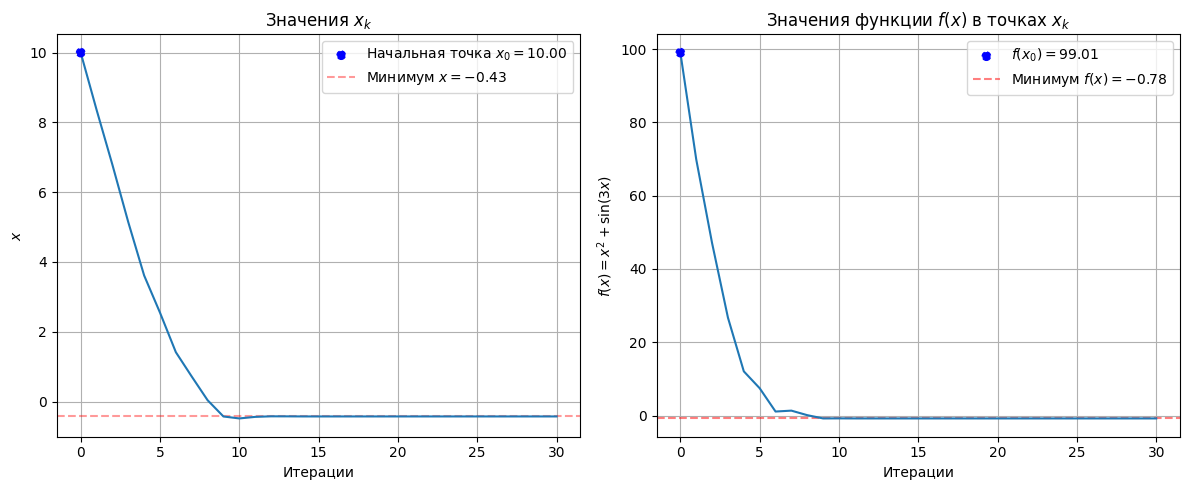

In [ ]:
def nonconv_func_nag(x: Array) -> float:
    return x[0] ** 2 + math.sin(3.0 * x[0])  # L = 11


def grad_nonconv_func_nag(x: Array) -> Array:
    return np.array(
        [2.0 * x[0] + 3.0 * math.cos(3.0 * x[0])], dtype=np.float64
    )


x0: Array = np.array([10.0], dtype=np.float64)
T: int = 30
r: int = 3
alpha: Callable[[int], float] = lambda k: 0.08  # < 0.(09) = 1/L = 1/11
beta: Callable[[int], float] = lambda k: (k - 1) / (k + r - 1)

x_vals: List[Array] = nag(grad_nonconv_func_nag, x0, T, alpha, beta)
f_vals: List[float] = [nonconv_func_nag(x) for x in x_vals]

show(
    x_vals,
    f_vals,
    ylabel2=r"$f(x) = x^2 + \sin(3x)$",
    x_min=-0.427,
    f_min=-0.776,
)

alpha = 0.12
beta = 0.5194938532959157



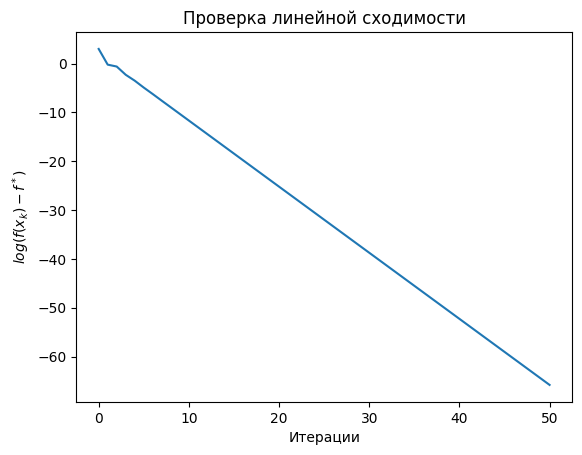

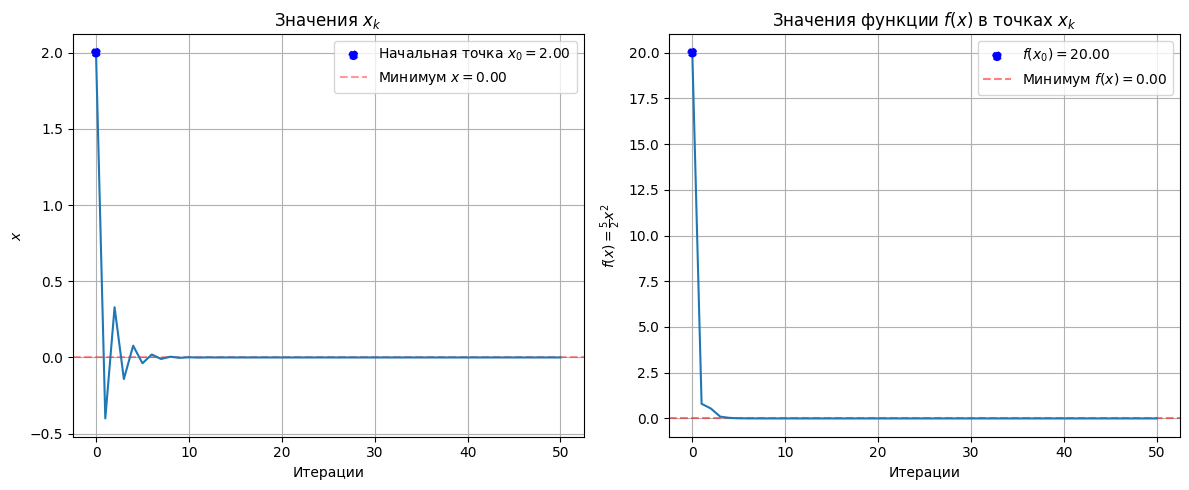

In [ ]:
L: float = 10.0
mu: float = 1.0


def strconv_func_nag(x: Array) -> float:
    return 0.5 * L * x[0] ** 2


def grad_strconv_func_nag(x: Array) -> Array:
    return np.array([L * x[0]], dtype=np.float64)


x0: Array = np.array([2.0], dtype=np.float64)
T: int = 50
kappa: float = L / mu

alpha: float = 1.2 / L
beta: float = (math.sqrt(kappa) - 1.0) / (math.sqrt(kappa) + 1.0)

x_vals: List[Array] = nag(
    grad_strconv_func_nag, x0, T, alpha=lambda k: alpha, beta=lambda k: beta
)
f_vals: List[float] = [strconv_func_nag(x) for x in x_vals]

print(f"alpha = {alpha}")
print(f"beta = {beta}\n")

plt.plot(range(len(f_vals)), np.log(f_vals))
plt.xlabel("Итерации")
plt.ylabel(r"$log(f(x_k) - f^*)$")
plt.title("Проверка линейной сходимости")
plt.show()

show(x_vals, f_vals, ylabel2=r"$f(x)= \frac{5}{2}x^2$")

alpha = 1.3


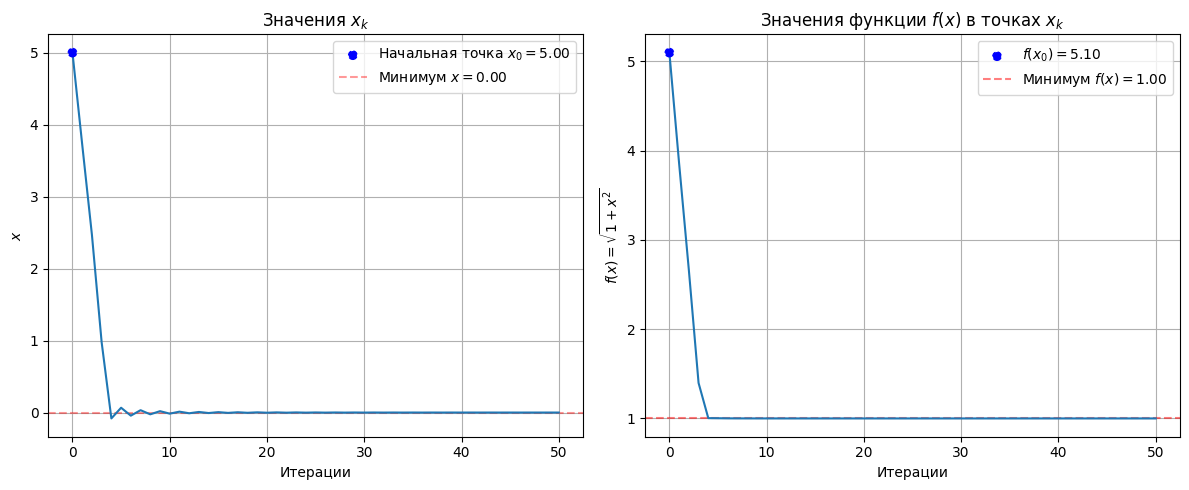

In [ ]:
def conv_func_nag(x: Array) -> float:  # L = 1
    return math.sqrt(1.0 + x[0] ** 2)


def grad_conv_func_nag(x: Array) -> Array:
    return np.array([x[0] / math.sqrt(1.0 + x[0] ** 2)], dtype=np.float64)


x0: Array = np.array([5.0], dtype=np.float64)
T: int = 50
r: int = 3
alpha: Callable[[int], float] = lambda k: 1.3  # 1/L = 1
beta: Callable[[int], float] = lambda k: (k - 1) / (k + r - 1)

x_vals: List[Array] = nag(grad_conv_func_nag, x0, T, alpha=alpha, beta=beta)
f_vals: List[float] = [conv_func_nag(x) for x in x_vals]

print(f"alpha = {alpha(0)}")

show(x_vals, f_vals, ylabel2=r"$f(x)= \sqrt{1 + x^2}$", f_min=1.0)